<a href="https://colab.research.google.com/github/kosar-am/rice-classification-cnn/blob/main/notebooks/03_prediction_and_inference.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Rice Image Classification - Prediction and Inference

## Project Objective
This notebook demonstrates how to use the trained CNN model for image classification.

The workflow includes:

- Loading the trained model
- Uploading a new rice image
- Preprocessing the image
- Predicting the rice variety
- Displaying the prediction confidence

## Import Required Libraries

In [8]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os
from google.colab import files

## Mount Google Drive

In [2]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


## Load the Trained Model

In [3]:
# Project paths

PROJECT_PATH = "/content/drive/MyDrive/My-Project/Rice-Classification-2026"

TENSORFLOW_PATH = f"{PROJECT_PATH}/tensorflow"

MODEL_PATH = f"{TENSORFLOW_PATH}/models/rice_cnn_model2026.keras"

In [4]:
# Verify Model Path
print("Model exists:", os.path.exists(MODEL_PATH))

Model exists: True


In [5]:
# Load the trained TensorFlow model

loaded_model = tf.keras.models.load_model(MODEL_PATH)

print("Model loaded successfully!")

Model loaded successfully!


## Inspect the Loaded Model

In [6]:
# Display the model architecture

loaded_model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 250, 250, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 125, 125, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 62, 62, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 31, 31, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 331,217 (1.26 MB)

 Trainable params: 110,405 (431.27 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 220,812 (862.55 KB)

## Upload an Image

In [9]:
# Upload an image from the computer

uploaded = files.upload()

Saving 11.png to 11.png


In [10]:
# Get the uploaded file name

image_filename = next(iter(uploaded))

print("Uploaded image:", image_filename)

Uploaded image: 11.png


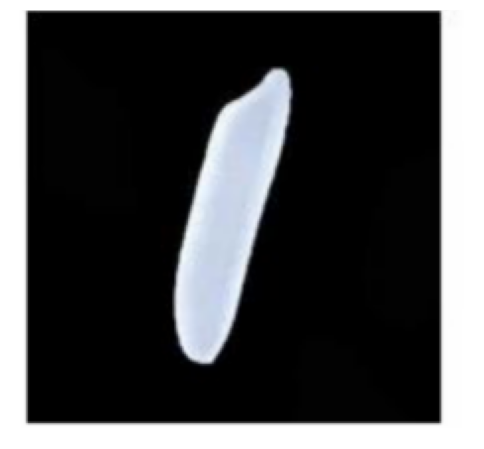

In [11]:
# Load the uploaded image

image = tf.keras.utils.load_img(image_filename)

# Display the image

plt.figure(figsize=(6, 6))
plt.imshow(image)
plt.axis("off")
plt.show()

## Preprocess the Image

In [12]:
# Resize the image

image = tf.keras.utils.load_img(
    image_filename,
    target_size=(250, 250)
)

# Convert the image to a NumPy array

image_array = tf.keras.utils.img_to_array(image)

# Normalize pixel values

image_array = image_array / 255.0

# Add a batch dimension

image_array = tf.expand_dims(image_array, axis=0)

In [13]:
print(image_array.shape)

(1, 250, 250, 3)


## Predict the Rice Variety

In [14]:
# Predict the rice variety

prediction = loaded_model.predict(image_array)

print(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
[[0.0000000e+00 1.0000000e+00 0.0000000e+00 1.8746444e-28 0.0000000e+00]]


## Find the Predicted Class

In [15]:
# Find the predicted class index

predicted_class_index = np.argmax(prediction)

print("Predicted class index:", predicted_class_index)

Predicted class index: 1


In [16]:
# Class labels

class_names = [
    "Arborio",
    "Basmati",
    "Ipsala",
    "Jasmine",
    "Karacadag"
]

print(class_names)

['Arborio', 'Basmati', 'Ipsala', 'Jasmine', 'Karacadag']


In [17]:
# Display the predicted class name

predicted_class = class_names[predicted_class_index]

print("Predicted class:", predicted_class)

Predicted class: Basmati


## Calculate Prediction Confidence

In [18]:
# Get the confidence score

confidence = np.max(prediction)

print(f"Confidence: {confidence * 100:.2f}%")

Confidence: 100.00%


## Display Prediction Results

In [19]:
# Display the prediction probability for each class

for class_name, probability in zip(class_names, prediction[0]):
    print(f"{class_name}: {probability * 100:.2f}%")

Arborio: 0.00%
Basmati: 100.00%
Ipsala: 0.00%
Jasmine: 0.00%
Karacadag: 0.00%


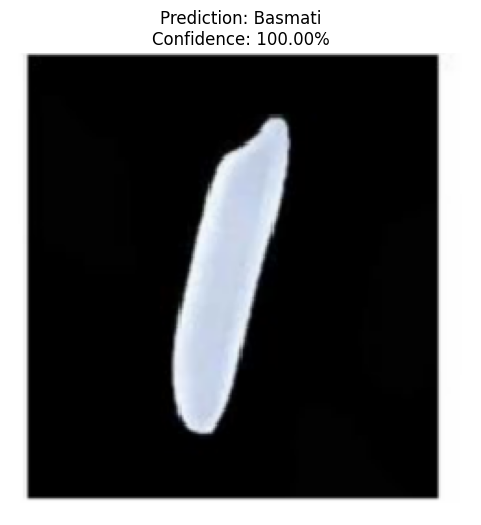

In [20]:
# Display the prediction result

plt.figure(figsize=(6, 6))
plt.imshow(image)
plt.axis("off")

plt.title(
    f"Prediction: {predicted_class}\n"
    f"Confidence: {confidence * 100:.2f}%"
)

plt.show()